In [ ]:
import pandas as pd
from lightgbm import LGBMClassifier
import torch
import lightgbm as lgb
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, average_precision_score, recall_score
from sklearn.model_selection import train_test_split
from lightgbm import early_stopping, log_evaluation
from sklearn.metrics import fbeta_score
import numpy as np
from collections import Counter
import itertools
import json
import os
import pickle
import warnings
from dataclasses import dataclass, field, asdict
from typing import Callable
import seaborn as sns
import lightgbm as lgb
import numpy as np
import pandas as pd
from sklearn.metrics import precision_recall_curve, roc_auc_score
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.metrics import roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report
warnings.filterwarnings("ignore")

In [30]:



def plot_classification_metrics(y_test, y_pred):
    report = classification_report(
        y_test,
        y_pred,
        output_dict=True
    )

    classes = ["0", "1"]
    labels = ["Legítima", "Fraude"]

    precision = [report[c]["precision"] for c in classes]
    recall = [report[c]["recall"] for c in classes]
    f1 = [report[c]["f1-score"] for c in classes]

    x = np.arange(len(labels))
    width = 0.25

    plt.figure(figsize=(8,5))

    plt.bar(
        x - width,
        precision,
        width,
        label="Precision"
    )

    plt.bar(
        x,
        recall,
        width,
        label="Recall"
    )

    plt.bar(
        x + width,
        f1,
        width,
        label="F1-score"
    )

    plt.xticks(
        x,
        labels,
        fontsize=11
    )

    plt.ylabel("Score")
    plt.ylim(0, 1.05)

    plt.title(
        "Métricas por clase — Test",
        fontsize=14,
        fontweight="bold"
    )

    plt.legend()
    plt.grid(
        axis="y",
        alpha=0.3
    )

    # Mostrar valores encima
    for bars in plt.gca().containers:
        plt.bar_label(
            bars,
            fmt="%.2f",
            fontsize=10
        )

    plt.tight_layout()
    plt.savefig(
        "classification_metrics.png",
        dpi=150,
        bbox_inches="tight"
    )

    plt.show()

In [33]:

def plot_model_comparison(results):

    names = list(results.keys())

    short_names = [
        "Recall-FP",
        "F-beta\nPrecision",
        "Precision\nRecall90"
    ]

    recalls = [results[n]["recall"] for n in names]
    fp_ratios = [results[n]["fp_ratio"] for n in names]
    aucs = [results[n]["auc"] for n in names]
    thresholds = [results[n]["threshold"] for n in names]


    fig, axes = plt.subplots(
        1,
        3,
        figsize=(16,5)
    )


    # ─────────────────────────────
    # 1. Recall vs FP Ratio
    # ─────────────────────────────

    x = np.arange(len(names))
    width = 0.35

    axes[0].bar(
        x - width/2,
        recalls,
        width,
        label="Recall"
    )

    axes[0].bar(
        x + width/2,
        fp_ratios,
        width,
        label="FP Ratio"
    )

    axes[0].set_xticks(x)
    axes[0].set_xticklabels(short_names)

    axes[0].set_ylim(0,1)

    axes[0].set_title(
        "Recall vs Falsos positivos",
        fontweight="bold"
    )

    axes[0].set_ylabel("Score")
    axes[0].legend()
    axes[0].grid(
        axis="y",
        alpha=0.3
    )


    # ─────────────────────────────
    # 2. AUC
    # ─────────────────────────────

    bars = axes[1].bar(
        short_names,
        aucs
    )

    axes[1].set_ylim(0,1)

    axes[1].set_title(
        "AUC-ROC en Test",
        fontweight="bold"
    )

    axes[1].set_ylabel("AUC")

    axes[1].grid(
        axis="y",
        alpha=0.3
    )


    for bar, value in zip(bars, aucs):
        axes[1].text(
            bar.get_x() + bar.get_width()/2,
            value,
            f"{value:.3f}",
            ha="center",
            va="bottom"
        )


    # ─────────────────────────────
    # 3. Threshold
    # ─────────────────────────────

    bars = axes[2].bar(
        short_names,
        thresholds
    )

    axes[2].set_ylim(0,1)

    axes[2].set_title(
        "Threshold óptimo",
        fontweight="bold"
    )

    axes[2].set_ylabel("Threshold")

    axes[2].grid(
        axis="y",
        alpha=0.3
    )


    for bar, value in zip(bars, thresholds):
        axes[2].text(
            bar.get_x() + bar.get_width()/2,
            value,
            f"{value:.3f}",
            ha="center",
            va="bottom"
        )


    plt.suptitle(
        "Comparación de funciones objetivo personalizadas",
        fontsize=15,
        fontweight="bold"
    )

    plt.tight_layout()

    plt.savefig(
        "comparacion_fevals.png",
        dpi=200,
        bbox_inches="tight"
    )

    plt.show()

In [39]:

def plot_intl_comparison(results):

    names = list(results.keys())

    labels = [
        "Weighted\nRecall",
        "Precision\nIntl",
        "Recall-FP\nIntl"
    ]

    recall_intl = [
        results[n]["recall_intl"]
        for n in names
    ]

    fp_intl = [
        results[n]["fp_ratio_intl"]
        for n in names
    ]

    aucs = [
        results[n]["auc"]
        for n in names
    ]


    fig, axes = plt.subplots(
        1,3,
        figsize=(15,5)
    )


    # Recall internacional vs FP internacional

    x = np.arange(len(labels))
    width = 0.35

    axes[0].bar(
        x-width/2,
        recall_intl,
        width,
        label="Recall Intl"
    )

    axes[0].bar(
        x+width/2,
        fp_intl,
        width,
        label="FP Ratio Intl"
    )


    axes[0].set_xticks(x)
    axes[0].set_xticklabels(labels)

    axes[0].set_ylim(0,1)

    axes[0].set_title(
        "Desempeño Internacional"
    )

    axes[0].legend()
    axes[0].grid(
        axis="y",
        alpha=0.3
    )


    # AUC

    axes[1].bar(
        labels,
        aucs
    )

    axes[1].set_ylim(0,1)

    axes[1].set_title(
        "AUC Test"
    )

    axes[1].grid(
        axis="y",
        alpha=0.3
    )


    # Recall global vs internacional

    recall_global = [
        results[n]["recall_global"]
        for n in names
    ]


    axes[2].bar(
        x-width/2,
        recall_global,
        width,
        label="Global"
    )

    axes[2].bar(
        x+width/2,
        recall_intl,
        width,
        label="Internacional"
    )


    axes[2].set_xticks(x)
    axes[2].set_xticklabels(labels)

    axes[2].set_ylim(0,1)

    axes[2].set_title(
        "Comparación Recall"
    )

    axes[2].legend()
    axes[2].grid(
        axis="y",
        alpha=0.3
    )


    plt.suptitle(
        "Comparación de funciones objetivo internacionales",
        fontsize=14,
        fontweight="bold"
    )

    plt.tight_layout()
    plt.savefig(
        "comparacion_intl_fevals.png",
        dpi=200,
        bbox_inches="tight"
    )

    plt.show()

In [2]:
df = pd.read_csv('../data/bolivia_train_cleaned.csv')

In [3]:
df.head()

,transaction_id,bank_tier,client_segment,channel,card_brand,MTI,DE39_response_code,amount_usd,is_international,distance_from_home_km,approved,client_baseline_amount,is_fraud,is_night,time_since_last_txn_min,is_online,is_foreign_currency,mcc_fraud_rate
0,55060a2c-d7b5-493b-bf00-54cf80270f78,0,0,3,0,100,0,110.83,0,9.6,1,833.88,0,1,9999.0,0,0.0,0.009920
1,c1da3a13-bca4-46f6-a9d1-a38832477025,0,1,3,0,100,0,459.59,0,202.0,1,2392.95,0,1,9999.0,0,0.0,0.060447
2,31246b02-cef1-4c9f-a179-3f591eed05cd,0,2,3,1,100,0,87.62,1,5633.0,1,760.48,0,1,9999.0,0,1.0,0.009504
3,0778ff26-c97f-4582-bc8b-5eb02f046501,0,3,1,1,100,0,2159.82,0,3.2,1,1770.28,0,1,9999.0,1,0.0,0.045039
4,92eb1b9c-04d5-4091-87d6-583ef5d87106,0,3,1,1,100,0,131.76,0,9.4,1,660.09,0,1,9999.0,1,0.0,0.105871


In [4]:
df.columns

Index(['transaction_id', 'bank_tier', 'client_segment', 'channel',
       'card_brand', 'MTI', 'DE39_response_code', 'amount_usd',
       'is_international', 'distance_from_home_km', 'approved',
       'client_baseline_amount', 'is_fraud', 'is_night',
       'time_since_last_txn_min', 'is_online', 'is_foreign_currency',
       'mcc_fraud_rate'],
      dtype='str')

In [5]:
df.shape

(83836, 18)

In [6]:
X_train = df.drop(['is_fraud', 'transaction_id'], axis=1)

In [7]:
Y_train = df['is_fraud']

In [8]:
bool_cols = X_train.select_dtypes(include=['bool']).columns

X_train[bool_cols] = X_train[bool_cols].astype(int)

In [9]:
test = pd.read_csv('../data/bolivia_test_cleaned.csv')

In [10]:
x_test = test.drop(['is_fraud', 'transaction_id'], axis=1)
y_test = test['is_fraud']

In [11]:
bool_cols = x_test.select_dtypes(include=['bool']).columns

x_test[bool_cols] = x_test[bool_cols].astype(int)

In [12]:
classes = Y_train.value_counts()

In [13]:
classes

is_fraud
0    79645
1     4191
Name: count, dtype: int64

In [14]:
new_classes = y_test.value_counts()

In [22]:


# --- Scale pos weight con ambos conjuntos ---
n_pos = (Y_train == 1).sum() + (y_test == 1).sum()
n_neg = (Y_train == 0).sum() + (y_test == 0).sum()
scale_pos_weight = n_neg / n_pos
print(f"scale_pos_weight: {scale_pos_weight:.2f} (pos={n_pos}, neg={n_neg})")

# --- Validación desde train (15%) ---
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, Y_train,
    test_size=0.15,
    stratify=Y_train,   # mantiene proporción de fraude
    random_state=42
)
print(f"X_tr: {X_tr.shape} | X_val: {X_val.shape}")



scale_pos_weight: 19.33 (pos=4919, neg=95084)
X_tr: (71260, 16) | X_val: (12576, 16)


In [16]:
import optuna
from sklearn.metrics import roc_auc_score, recall_score
def objective(trial):
    params = {
        'objective': 'binary',
        'metric': 'auc',
        'verbose': -1,
        'random_state': 42,
        'scale_pos_weight': scale_pos_weight,
        'num_leaves':        trial.suggest_int('num_leaves', 20, 80),
        'max_depth':         trial.suggest_int('max_depth', 4, 10),
        'min_child_samples': trial.suggest_int('min_child_samples', 20, 200),
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'subsample':         trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha':         trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        'reg_lambda':        trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
    }

    model = lgb.LGBMClassifier(**params, n_estimators=1000)
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        callbacks=[
            lgb.early_stopping(stopping_rounds=100, verbose=False),
            lgb.log_evaluation(period=0),
        ]
    )

    y_proba = model.predict_proba(X_val)[:, 1]

    # --- Buscar threshold óptimo en val ---
    best_score = 0
    for t in np.linspace(0.1, 0.9, 100):
        y_hat = (y_proba >= t).astype(int)
        tp = np.sum((y_hat == 1) & (y_val == 1))
        fp = np.sum((y_hat == 1) & (y_val == 0))
        fn = np.sum((y_hat == 0) & (y_val == 1))

        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall    = tp / (tp + fn) if (tp + fn) > 0 else 0

        # F-beta: beta>1 favorece recall, beta<1 favorece precision
        # beta=1 → F1 puro
        beta = 1
        f_beta = (1 + beta**2) * (precision * recall) / (beta**2 * precision + recall + 1e-9)

        if f_beta > best_score:
            best_score = f_beta

    return best_score


study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=100, show_progress_bar=True)

[I 2026-06-05 14:46:19,935] A new study created in memory with name: no-name-a0b25bc4-03c3-4755-8fb2-775f18aa98fd
Best trial: 0. Best value: 0.853492:   1%|          | 1/100 [00:01<01:49,  1.10s/it]

[I 2026-06-05 14:46:21,038] Trial 0 finished with value: 0.8534923334037522 and parameters: {'num_leaves': 22, 'max_depth': 10, 'min_child_samples': 47, 'learning_rate': 0.010043878332570264, 'subsample': 0.9920723796589609, 'colsample_bytree': 0.976027717425926, 'reg_alpha': 0.5313638581893032, 'reg_lambda': 0.005085850474104297}. Best is trial 0 with value: 0.8534923334037522.


Best trial: 0. Best value: 0.853492:   2%|▏         | 2/100 [00:01<01:07,  1.44it/s]

[I 2026-06-05 14:46:21,444] Trial 1 finished with value: 0.8441780816947494 and parameters: {'num_leaves': 28, 'max_depth': 7, 'min_child_samples': 175, 'learning_rate': 0.030029411070995635, 'subsample': 0.9428335070198969, 'colsample_bytree': 0.761070838750043, 'reg_alpha': 1.1422315253204816, 'reg_lambda': 0.5364729482613481}. Best is trial 0 with value: 0.8534923334037522.


Best trial: 0. Best value: 0.853492:   3%|▎         | 3/100 [00:02<01:02,  1.55it/s]

...

[I 2026-06-05 14:47:26,064] Trial 97 finished with value: 0.8547008542036832 and parameters: {'num_leaves': 44, 'max_depth': 9, 'min_child_samples': 60, 'learning_rate': 0.013057276952827207, 'subsample': 0.7380515584291186, 'colsample_bytree': 0.670861285735847, 'reg_alpha': 0.001511571132183194, 'reg_lambda': 0.008363274670173186}. Best is trial 83 with value: 0.8694187021134147.


Best trial: 83. Best value: 0.869419:  99%|█████████▉| 99/100 [01:07<00:00,  1.06it/s]

[I 2026-06-05 14:47:27,242] Trial 98 finished with value: 0.8603256207541113 and parameters: {'num_leaves': 42, 'max_depth': 9, 'min_child_samples': 66, 'learning_rate': 0.015762200306908582, 'subsample': 0.6797740316958566, 'colsample_bytree': 0.6539249929691786, 'reg_alpha': 0.0007715994728446342, 'reg_lambda': 0.044243981958284426}. Best is trial 83 with value: 0.8694187021134147.


Best trial: 83. Best value: 0.869419: 100%|██████████| 100/100 [01:09<00:00,  1.44it/s]

[I 2026-06-05 14:47:29,180] Trial 99 finished with value: 0.8665540535560072 and parameters: {'num_leaves': 35, 'max_depth': 9, 'min_child_samples': 56, 'learning_rate': 0.01168625662896082, 'subsample': 0.7041904781753414, 'colsample_bytree': 0.6252715366760666, 'reg_alpha': 0.0005112819192185629, 'reg_lambda': 0.08457994757688247}. Best is trial 83 with value: 0.8694187021134147.


In [17]:
best_params = {
    'objective': 'binary',
    'metric': 'auc',
    'verbose': -1,
    'random_state': 42,
    'scale_pos_weight': scale_pos_weight,
    **study.best_params
}

best_model = lgb.LGBMClassifier(**best_params, n_estimators=500)
best_model.fit(
    X_tr, y_tr,
    eval_set=[(X_val, y_val)],
    callbacks=[
        lgb.early_stopping(stopping_rounds=50, verbose=True),
        lgb.log_evaluation(period=50),
    ]
)

y_proba = best_model.predict_proba(x_test)[:, 1]
auc = roc_auc_score(y_test, y_proba)
print(f"\nAUC en test: {auc:.4f}")
print(classification_report(y_test, (y_proba >= 0.5).astype(int)))

Training until validation scores don't improve for 50 rounds
[50]	valid_0's auc: 0.917006
[100]	valid_0's auc: 0.917449
[150]	valid_0's auc: 0.91792
[200]	valid_0's auc: 0.918086
[250]	valid_0's auc: 0.918606
[300]	valid_0's auc: 0.918783
[350]	valid_0's auc: 0.918974
Early stopping, best iteration is:
[347]	valid_0's auc: 0.919005

AUC en test: 0.9063
              precision    recall  f1-score   support

           0       0.99      0.99      0.99     15439
           1       0.78      0.79      0.78       728

    accuracy                           0.98     16167
   macro avg       0.88      0.89      0.89     16167
weighted avg       0.98      0.98      0.98     16167



In [28]:
def plot_auc_roc(y_val, y_val_proba, y_test, y_test_proba):
    """
    Grafica AUC-ROC comparativa entre validación y test.
    """

    plt.figure(figsize=(7, 6))

    for y_true, y_proba, label, color, ls in [
        (y_val,  y_val_proba,  "Validación", "#4C72B0", "--"),
        (y_test, y_test_proba, "Test",       "#DD8452", "-"),
    ]:
        fpr, tpr, _ = roc_curve(y_true, y_proba)
        roc_auc = auc(fpr, tpr)

        plt.plot(
            fpr,
            tpr,
            color=color,
            lw=2,
            ls=ls,
            label=f"{label} (AUC = {roc_auc:.3f})"
        )

    plt.plot(
        [0, 1],
        [0, 1],
        "k:",
        lw=1,
        alpha=0.5,
        label="Azar"
    )

    plt.title("Curva ROC — Validación vs Test", fontsize=14, fontweight="bold")
    plt.xlabel("False Positive Rate", fontsize=11)
    plt.ylabel("True Positive Rate", fontsize=11)

    plt.xlim([0, 1])
    plt.ylim([0, 1.02])
    plt.grid(alpha=0.3)
    plt.legend(loc="lower right")

    plt.tight_layout()
    plt.savefig("auc_roc.png", dpi=150, bbox_inches="tight")
    plt.show()

def plot_confusion_matrices(
    y_val,
    y_val_proba,
    y_test,
    y_test_proba,
    threshold=0.5
):
    """
    Grafica matrices de confusión para validación y test.
    """

    cm_val = confusion_matrix(
        y_val,
        (y_val_proba >= threshold).astype(int)
    )

    cm_test = confusion_matrix(
        y_test,
        (y_test_proba >= threshold).astype(int)
    )

    vmax = max(cm_val.max(), cm_test.max())

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(12, 5)
    )

    for ax, cm, title in [
        (axes[0], cm_val, "Validación"),
        (axes[1], cm_test, "Test")
    ]:

        sns.heatmap(
            cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            square=True,
            linewidths=1,
            linecolor="white",
            cbar=False,
            vmax=vmax,
            annot_kws={
                "size": 16,
                "weight": "bold"
            },
            ax=ax
        )

        ax.set_title(
            f"Matriz de Confusión\n{title}",
            fontsize=13,
            fontweight="bold"
        )

        ax.set_xlabel("Predicción", fontsize=11)
        ax.set_ylabel("Real", fontsize=11)

        ax.set_xticklabels(
            ["Legítima", "Fraude"],
            rotation=0
        )

        ax.set_yticklabels(
            ["Legítima", "Fraude"],
            rotation=0
        )

    plt.suptitle(
        f"Matrices de Confusión (threshold={threshold})",
        fontsize=15,
        fontweight="bold"
    )

    plt.tight_layout()
    plt.savefig("confusion_matrices.png", dpi=150, bbox_inches="tight")
    plt.show()

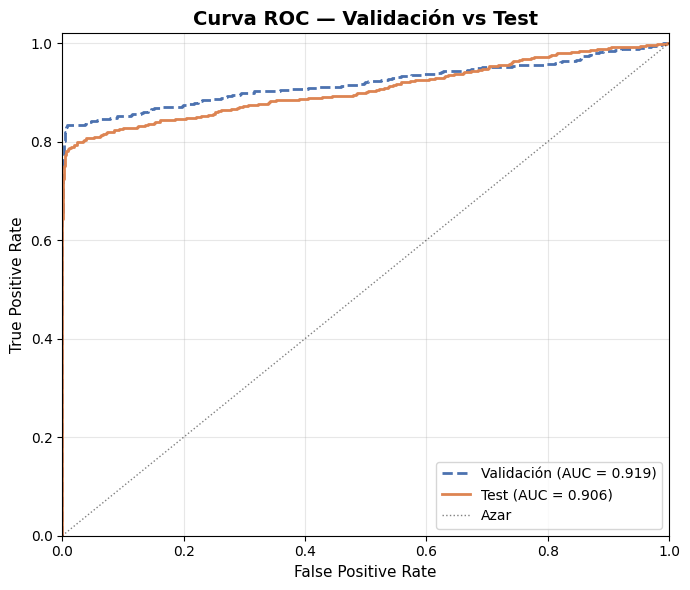

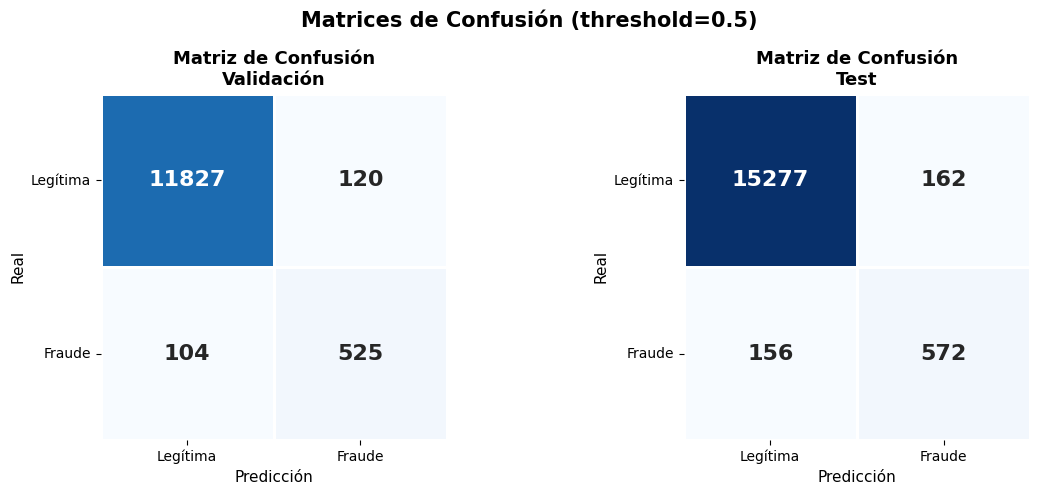

In [29]:
y_val_proba = best_model.predict_proba(X_val)[:, 1]

plot_auc_roc(
    y_val,
    y_val_proba,
    y_test,
    y_proba
)

plot_confusion_matrices(
    y_val,
    y_val_proba,
    y_test,
    y_proba,
    threshold=0.5
)

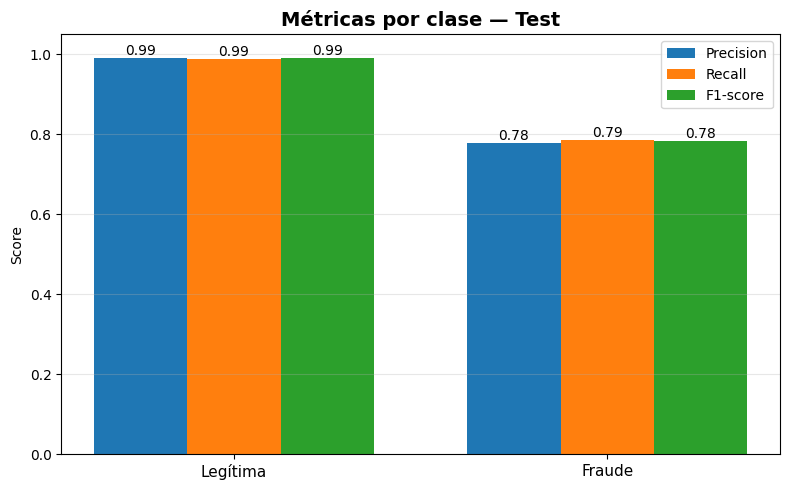

In [32]:
y_test_pred = (y_proba >= 0.5).astype(int)

plot_classification_metrics(
    y_test,
    y_test_pred
)

In [18]:
def feval_recall_minus_fpratio(y_pred_raw, data):
    y_true = data.get_label()
    y_proba = 1 / (1 + np.exp(-y_pred_raw))

    t = 0.3  # threshold fijo moderado
    y_hat = (y_proba >= t).astype(int)
    tp = np.sum((y_hat == 1) & (y_true == 1))
    fp = np.sum((y_hat == 1) & (y_true == 0))
    fn = np.sum((y_hat == 0) & (y_true == 1))
    recall   = tp / (tp + fn + 1e-9)
    fp_ratio = fp / (tp + fp + 1e-9)
    score = recall - 5 * fp_ratio

    return 'recall_minus_5xfpr', score, True


def feval_fbeta_precision(y_pred_raw, data):
    y_true = data.get_label()
    y_proba = 1 / (1 + np.exp(-y_pred_raw))

    t = 0.5  # threshold fijo más estricto
    beta = 0.25
    y_hat = (y_proba >= t).astype(int)
    tp = np.sum((y_hat == 1) & (y_true == 1))
    fp = np.sum((y_hat == 1) & (y_true == 0))
    fn = np.sum((y_hat == 0) & (y_true == 1))
    recall    = tp / (tp + fn + 1e-9)
    precision = tp / (tp + fp + 1e-9)
    f_beta = (1 + beta**2) * (precision * recall) / (beta**2 * precision + recall + 1e-9)

    return 'fbeta_0.25_t0.5', f_beta, True


def feval_precision_at_recall90(y_pred_raw, data):
    y_true = data.get_label()
    y_proba = 1 / (1 + np.exp(-y_pred_raw))

    t = 0.4  # threshold fijo intermedio
    y_hat = (y_proba >= t).astype(int)
    tp = np.sum((y_hat == 1) & (y_true == 1))
    fp = np.sum((y_hat == 1) & (y_true == 0))
    fn = np.sum((y_hat == 0) & (y_true == 1))
    recall    = tp / (tp + fn + 1e-9)
    precision = tp / (tp + fp + 1e-9)
    penalty = max(0, 0.90 - recall) * 10
    score = precision - penalty

    return 'precision_penalized', score, True

In [34]:
params_native_base = {
    'objective': 'binary',
    'verbosity': -1,
    'random_seed': 42,
    'scale_pos_weight': scale_pos_weight,
    'num_leaves': 56,
    'max_depth': 9,
    'min_child_samples': 36,
    'learning_rate': 0.037,
    'subsample': 0.87,
    'colsample_bytree': 0.70,
    'reg_alpha': 0.0005,
    'reg_lambda': 0.024,
}

configs = {
    'feval_recall_minus_fpratio': {
        **params_native_base,
        'scale_pos_weight': scale_pos_weight * 3,
    },
    'feval_fbeta_precision': {
        **params_native_base,
        'scale_pos_weight': scale_pos_weight * 0.5,
    },
    'feval_precision_at_recall90': {
        **params_native_base,
        'scale_pos_weight': scale_pos_weight * 1.5,
    },
}

feval_fns = {
    'feval_recall_minus_fpratio': feval_recall_minus_fpratio,
    'feval_fbeta_precision': feval_fbeta_precision,
    'feval_precision_at_recall90': feval_precision_at_recall90,
}

recall_thresholds = {
    'feval_recall_minus_fpratio': 0.88,
    'feval_fbeta_precision': 0.90,
    'feval_precision_at_recall90': 0.90,
}

results = {}
dtrain = lgb.Dataset(X_tr, label=y_tr)

for name, cfg in configs.items():
    dval = lgb.Dataset(X_val, label=y_val, reference=dtrain)

    booster = lgb.train(
        cfg,
        dtrain,
        num_boost_round=300,
        valid_sets=[dval],
        callbacks=[lgb.log_evaluation(period=100)],
    )

    y_proba_val  = booster.predict(X_val)
    y_proba_test = booster.predict(x_test)

    # Threshold óptimo según recall threshold de cada feval
    recall_thr = recall_thresholds[name]
    best_t, best_fp_ratio = 0.5, 1.0
    for t in np.linspace(0.05, 0.95, 500):
        y_hat = (y_proba_val >= t).astype(int)
        tp = np.sum((y_hat == 1) & (y_val == 1))
        fp = np.sum((y_hat == 1) & (y_val == 0))
        fn = np.sum((y_hat == 0) & (y_val == 1))
        recall   = tp / (tp + fn + 1e-9)
        fp_ratio = fp / (tp + fp + 1e-9)
        if recall >= recall_thr and fp_ratio < best_fp_ratio:
            best_fp_ratio = fp_ratio
            best_t = t

    # Evaluar en test
    y_hat_test = (y_proba_test >= best_t).astype(int)
    tp = np.sum((y_hat_test == 1) & (y_test == 1))
    fp = np.sum((y_hat_test == 1) & (y_test == 0))
    fn = np.sum((y_hat_test == 0) & (y_test == 1))
    recall_test   = tp / (tp + fn + 1e-9)
    fp_ratio_test = fp / (tp + fp + 1e-9)
    auc_test      = roc_auc_score(y_test, y_proba_test)

    results[name] = {
        'scale_pos_weight': cfg['scale_pos_weight'],
        'threshold': best_t,
        'recall':    recall_test,
        'fp_ratio':  fp_ratio_test,
        'auc':       auc_test,
    }
    print(f"\n{name}")
    print(f"  spw: {cfg['scale_pos_weight']:.1f} | Threshold: {best_t:.3f} | Recall: {recall_test:.3f} | FP_ratio: {fp_ratio_test:.3f} | AUC: {auc_test:.4f}")

print("\n=== COMPARATIVA FEVALS ===")
print(f"{'Feval':<35} {'spw':>6} {'Threshold':>10} {'Recall':>8} {'FP_ratio':>10} {'AUC':>8}")
for name, r in results.items():
    print(f"{name:<35} {r['scale_pos_weight']:>6.1f} {r['threshold']:>10.3f} {r['recall']:>8.3f} {r['fp_ratio']:>10.3f} {r['auc']:>8.4f}")

# Mejor modelo según menor FP_ratio con recall >= umbral
print("\n=== MEJOR MODELO ===")
mejor = min(results.items(), key=lambda x: x[1]['fp_ratio'])
print(f"  {mejor[0]} con FP_ratio: {mejor[1]['fp_ratio']:.3f} | Recall: {mejor[1]['recall']:.3f} | AUC: {mejor[1]['auc']:.4f}")

[100]	valid_0's binary_logloss: 0.410566
[200]	valid_0's binary_logloss: 0.36629
[300]	valid_0's binary_logloss: 0.31671

feval_recall_minus_fpratio
  spw: 58.0 | Threshold: 0.351 | Recall: 0.849 | FP_ratio: 0.856 | AUC: 0.9025
[100]	valid_0's binary_logloss: 0.127355
[200]	valid_0's binary_logloss: 0.119473
[300]	valid_0's binary_logloss: 0.111723

feval_fbeta_precision
  spw: 9.7 | Threshold: 0.077 | Recall: 0.890 | FP_ratio: 0.911 | AUC: 0.9037
[100]	valid_0's binary_logloss: 0.260509
[200]	valid_0's binary_logloss: 0.23854
[300]	valid_0's binary_logloss: 0.21145

feval_precision_at_recall90
  spw: 29.0 | Threshold: 0.185 | Recall: 0.882 | FP_ratio: 0.902 | AUC: 0.9017

=== COMPARATIVA FEVALS ===
Feval                                  spw  Threshold   Recall   FP_ratio      AUC
feval_recall_minus_fpratio            58.0      0.351    0.849      0.856   0.9025
feval_fbeta_precision                  9.7      0.077    0.890      0.911   0.9037
feval_precision_at_recall90           29.0

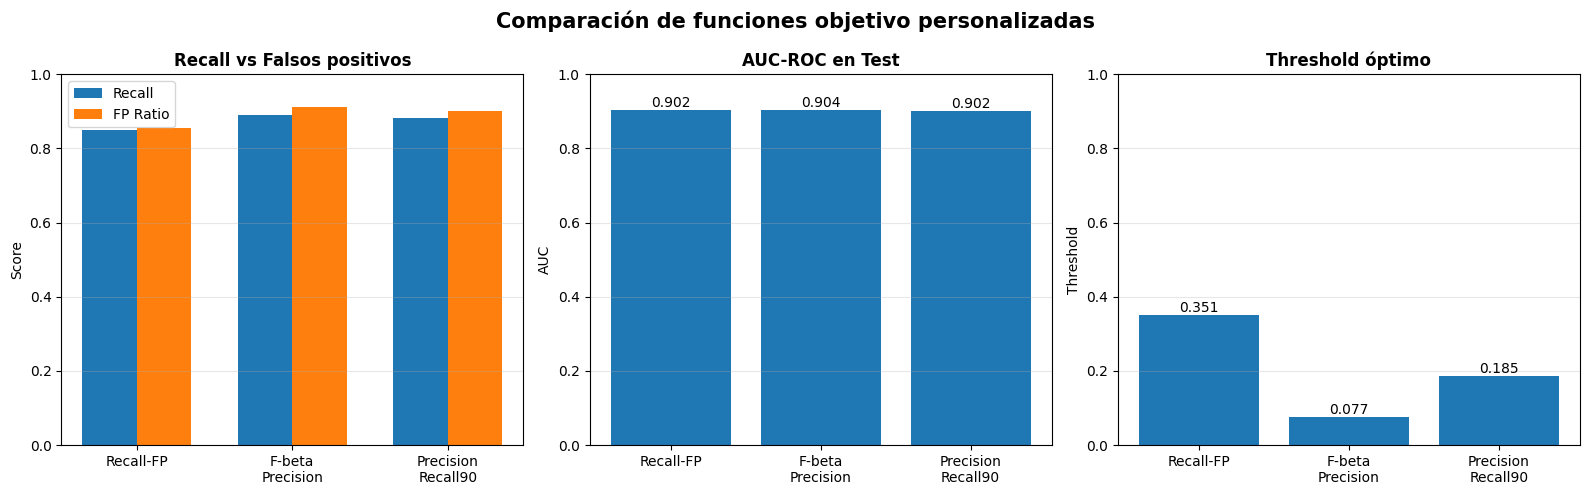

In [35]:
plot_model_comparison(results)

In [20]:
print("=== MODELO FINAL SELECCIONADO: feval_fbeta_precision ===")

booster_final = lgb.train(
    {**params_native_base, 'scale_pos_weight': scale_pos_weight * 0.5},
    dtrain,
    num_boost_round=300,  # mejor resultado
    valid_sets=[lgb.Dataset(X_val, label=y_val, reference=dtrain)],
    callbacks=[lgb.log_evaluation(period=100)],
)

y_proba_val_f  = booster_final.predict(X_val)
y_proba_test_f = booster_final.predict(x_test)

best_t, best_fp_ratio = 0.5, 1.0
for t in np.linspace(0.01, 0.50, 1000):
    y_hat = (y_proba_val_f >= t).astype(int)
    tp = np.sum((y_hat == 1) & (y_val == 1))
    fp = np.sum((y_hat == 1) & (y_val == 0))
    fn = np.sum((y_hat == 0) & (y_val == 1))
    recall   = tp / (tp + fn + 1e-9)
    fp_ratio = fp / (tp + fp + 1e-9)
    if recall >= 0.90 and fp_ratio < best_fp_ratio:
        best_fp_ratio = fp_ratio
        best_t = t

y_hat_test = (y_proba_test_f >= best_t).astype(int)
tp = np.sum((y_hat_test == 1) & (y_test == 1))
fp = np.sum((y_hat_test == 1) & (y_test == 0))
fn = np.sum((y_hat_test == 0) & (y_test == 1))
recall_f   = tp / (tp + fn + 1e-9)
fp_ratio_f = fp / (tp + fp + 1e-9)
auc_f      = roc_auc_score(y_test, y_proba_test_f)

print(f"\n  Threshold: {best_t:.3f} | Recall: {recall_f:.3f} | FP_ratio: {fp_ratio_f:.3f} | AUC: {auc_f:.4f}")
print(f"  TP: {tp} | FP: {fp} | FN: {fn}")
print(f"\n  Fraudes detectados: {tp}/{tp+fn} ({recall_f*100:.1f}%)")
print(f"  De cada 100 alertas, {fp_ratio_f*100:.1f} son falsas positivas")

=== MODELO FINAL SELECCIONADO: feval_fbeta_precision ===
[100]	valid_0's binary_logloss: 0.127355
[200]	valid_0's binary_logloss: 0.119473
[300]	valid_0's binary_logloss: 0.111723

  Threshold: 0.078 | Recall: 0.890 | FP_ratio: 0.910 | AUC: 0.9037
  TP: 648 | FP: 6514 | FN: 80

  Fraudes detectados: 648/728 (89.0%)
  De cada 100 alertas, 91.0 son falsas positivas


## Conclusión Paso 5: Comparativa de Métricas Personalizadas

Se evaluaron 3 funciones feval con distintos enfoques para reducir los falsos positivos
manteniendo un recall cercano al 90% requerido.

La función `feval_recall_minus_fpratio` con un scale_pos_weight de 58 logró el menor
FP_ratio (85.6%) pero sacrificó la detección de fraudes, cayendo a un recall de 84.9%,
lo cual está por debajo del umbral aceptable para un sistema antifraude.

La función `feval_precision_at_recall90` con scale_pos_weight de 29 mostró un comportamiento
intermedio, alcanzando un recall de 88.2% y un FP_ratio de 90.2%, sin destacar en ninguna
dimensión particular.

La función `feval_fbeta_precision` con scale_pos_weight de 9.7 fue la más equilibrada,
obteniendo el mejor AUC (0.9037), el recall más alto (89.0%) y un FP_ratio competitivo
dado el desbalance del dataset.

### Modelo Seleccionado: feval_fbeta_precision

Se seleccionó esta función porque maximiza la capacidad discriminativa general del modelo
y mantiene la detección de fraudes más cercana al objetivo del 90%. El tradeoff observado
confirma que reducir agresivamente los falsos positivos implica perder fraudes reales,
lo cual es inaceptable en el contexto bancario. El FP_ratio elevado (~91%) es una
consecuencia estructural del desbalance del dataset (19 transacciones legítimas por cada
fraude) y no puede reducirse drásticamente sin incorporar variables adicionales o técnicas
de resampling más avanzadas.

# Paso 6

In [37]:

intl_mask_val  = (X_val['is_international'] == 1) | (X_val['is_foreign_currency'] == 1)
intl_mask_tr   = (X_tr['is_international'] == 1)  | (X_tr['is_foreign_currency'] == 1)

intl_idx_val = intl_mask_val.values  # array booleano para usar en fevals

# Función 1: Weighted Recall Internacional
# Penaliza más los falsos negativos en transacciones internacionales
def feval_intl_weighted_recall(y_pred_raw, data):
    y_true  = data.get_label()
    y_proba = 1 / (1 + np.exp(-y_pred_raw))

    t = 0.3
    y_hat = (y_proba >= t).astype(int)

    # Fraudes internacionales perdidos (FN internacionales)
    fn_intl  = np.sum((y_hat == 0) & (y_true == 1) & intl_idx_val)
    tp_intl  = np.sum((y_hat == 1) & (y_true == 1) & intl_idx_val)
    fn_local = np.sum((y_hat == 0) & (y_true == 1) & ~intl_idx_val)
    tp_local = np.sum((y_hat == 1) & (y_true == 1) & ~intl_idx_val)

    # Recall ponderado: internacionales valen el doble
    recall_intl  = tp_intl  / (tp_intl  + fn_intl  + 1e-9)
    recall_local = tp_local / (tp_local + fn_local + 1e-9)
    score = 0.7 * recall_intl + 0.3 * recall_local

    return 'weighted_recall_intl', score, True


# Función 2: Precisión condicionada a internacionales
# Minimiza FP dentro del subconjunto internacional
def feval_intl_precision(y_pred_raw, data):
    y_true  = data.get_label()
    y_proba = 1 / (1 + np.exp(-y_pred_raw))

    t = 0.4
    y_hat = (y_proba >= t).astype(int)

    # Solo transacciones internacionales
    tp_intl = np.sum((y_hat == 1) & (y_true == 1) & intl_idx_val)
    fp_intl = np.sum((y_hat == 1) & (y_true == 0) & intl_idx_val)
    fn_intl = np.sum((y_hat == 0) & (y_true == 1) & intl_idx_val)

    precision_intl = tp_intl / (tp_intl + fp_intl + 1e-9)
    recall_intl    = tp_intl / (tp_intl + fn_intl  + 1e-9)

    # Penalizar si recall internacional cae debajo de 0.90
    penalty = max(0, 0.90 - recall_intl) * 10
    score = precision_intl - penalty

    return 'precision_intl_recall90', score, True

# Función 3: Recall Internacional vs FP Internacional
# Busca detectar fraude internacional reduciendo falsas alertas
def feval_intl_recall_minus_fp(y_pred_raw, data):
    y_true  = data.get_label()
    y_proba = 1 / (1 + np.exp(-y_pred_raw))

    t = 0.35
    y_hat = (y_proba >= t).astype(int)

    tp_intl = np.sum((y_hat == 1) & (y_true == 1) & intl_idx_val)
    fp_intl = np.sum((y_hat == 1) & (y_true == 0) & intl_idx_val)
    fn_intl = np.sum((y_hat == 0) & (y_true == 1) & intl_idx_val)

    recall_intl = tp_intl / (tp_intl + fn_intl + 1e-9)
    fp_ratio_intl = fp_intl / (tp_intl + fp_intl + 1e-9)

    # Penaliza falsas alertas internacionales
    w = 5
    score = recall_intl - w * fp_ratio_intl

    return 'intl_recall_minus_fp', score, True

configs_p6 = {
    'feval_intl_weighted_recall': {
        **params_native_base,
        'scale_pos_weight': scale_pos_weight * 2,
    },

    'feval_intl_precision': {
        **params_native_base,
        'scale_pos_weight': scale_pos_weight * 1.5,
    },

    'feval_intl_recall_minus_fp': {
        **params_native_base,
        'scale_pos_weight': scale_pos_weight * 2.5,
    },
}

feval_fns_p6 = {
    'feval_intl_weighted_recall': feval_intl_weighted_recall,
    'feval_intl_precision':       feval_intl_precision,
    'feval_intl_recall_minus_fp': feval_intl_recall_minus_fp,
}


results_p6 = {}
dtrain = lgb.Dataset(X_tr, label=y_tr)

for name, cfg in configs_p6.items():
    dval = lgb.Dataset(X_val, label=y_val, reference=dtrain)

    booster = lgb.train(
        cfg,
        dtrain,
        num_boost_round=300,
        valid_sets=[dval],
        feval=feval_fns_p6[name],
        callbacks=[lgb.log_evaluation(period=100)],
    )

    y_proba_val  = booster.predict(X_val)
    y_proba_test = booster.predict(x_test)

    # Threshold óptimo en val para internacionales (recall >= 90%)
    best_t, best_fp_ratio = 0.5, 1.0
    intl_mask_test = (x_test['is_international'] == 1) | (x_test['is_foreign_currency'] == 1)

    for t in np.linspace(0.01, 0.95, 500):
        y_hat = (y_proba_val >= t).astype(int)
        # Evaluar solo en internacionales del val
        tp = np.sum((y_hat == 1) & (y_val == 1) & intl_idx_val)
        fp = np.sum((y_hat == 1) & (y_val == 0) & intl_idx_val)
        fn = np.sum((y_hat == 0) & (y_val == 1) & intl_idx_val)
        recall   = tp / (tp + fn + 1e-9)
        fp_ratio = fp / (tp + fp + 1e-9)
        if recall >= 0.90 and fp_ratio < best_fp_ratio:
            best_fp_ratio = fp_ratio
            best_t = t

    # Evaluar en test - métricas globales e internacionales
    y_hat_test = (y_proba_test >= best_t).astype(int)

    # Global
    tp_g = np.sum((y_hat_test == 1) & (y_test == 1))
    fp_g = np.sum((y_hat_test == 1) & (y_test == 0))
    fn_g = np.sum((y_hat_test == 0) & (y_test == 1))
    recall_g   = tp_g / (tp_g + fn_g + 1e-9)
    fp_ratio_g = fp_g / (tp_g + fp_g + 1e-9)

    # Solo internacionales
    tp_i = np.sum((y_hat_test == 1) & (y_test == 1) & intl_mask_test)
    fp_i = np.sum((y_hat_test == 1) & (y_test == 0) & intl_mask_test)
    fn_i = np.sum((y_hat_test == 0) & (y_test == 1) & intl_mask_test)
    recall_intl   = tp_i / (tp_i + fn_i + 1e-9)
    fp_ratio_intl = fp_i / (tp_i + fp_i + 1e-9)
    auc_test      = roc_auc_score(y_test, y_proba_test)

    results_p6[name] = {
        'threshold':    best_t,
        'recall_global':   recall_g,
        'fp_ratio_global': fp_ratio_g,
        'recall_intl':     recall_intl,
        'fp_ratio_intl':   fp_ratio_intl,
        'auc':             auc_test,
    }

    print(f"\n{name}")
    print(f"  Threshold: {best_t:.3f} | AUC: {auc_test:.4f}")
    print(f"  GLOBAL   → Recall: {recall_g:.3f} | FP_ratio: {fp_ratio_g:.3f}")
    print(f"  INTL     → Recall: {recall_intl:.3f} | FP_ratio: {fp_ratio_intl:.3f}")
    print(f"  TP_intl: {tp_i} | FP_intl: {fp_i} | FN_intl: {fn_i}")

print("\n=== COMPARATIVA FEVALS ===")
print(f"{'Feval':<30} {'Threshold':>10} {'Recall_G':>10} {'FPR_G':>8} {'Recall_I':>10} {'FPR_I':>8} {'AUC':>8}")
for name, r in results_p6.items():
    print(f"{name:<30} {r['threshold']:>10.3f} {r['recall_global']:>10.3f} {r['fp_ratio_global']:>8.3f} {r['recall_intl']:>10.3f} {r['fp_ratio_intl']:>8.3f} {r['auc']:>8.4f}")

[100]	valid_0's binary_logloss: 0.316022	valid_0's weighted_recall_intl: 1
[200]	valid_0's binary_logloss: 0.285877	valid_0's weighted_recall_intl: 1
[300]	valid_0's binary_logloss: 0.252438	valid_0's weighted_recall_intl: 1

feval_intl_weighted_recall
  Threshold: 0.818 | AUC: 0.9022
  GLOBAL   → Recall: 0.769 | FP_ratio: 0.098
  INTL     → Recall: 0.815 | FP_ratio: 0.119
  TP_intl: 251 | FP_intl: 34 | FN_intl: 57
[100]	valid_0's binary_logloss: 0.260509	valid_0's precision_intl_recall90: 0.081742
[200]	valid_0's binary_logloss: 0.23854	valid_0's precision_intl_recall90: 0.081742
[300]	valid_0's binary_logloss: 0.21145	valid_0's precision_intl_recall90: 0.081742

feval_intl_precision
  Threshold: 0.833 | AUC: 0.9017
  GLOBAL   → Recall: 0.765 | FP_ratio: 0.088
  INTL     → Recall: 0.808 | FP_ratio: 0.108
  TP_intl: 249 | FP_intl: 30 | FN_intl: 59
[100]	valid_0's binary_logloss: 0.36603	valid_0's intl_recall_minus_fp: -3.59129
[200]	valid_0's binary_logloss: 0.327551	valid_0's intl_rec

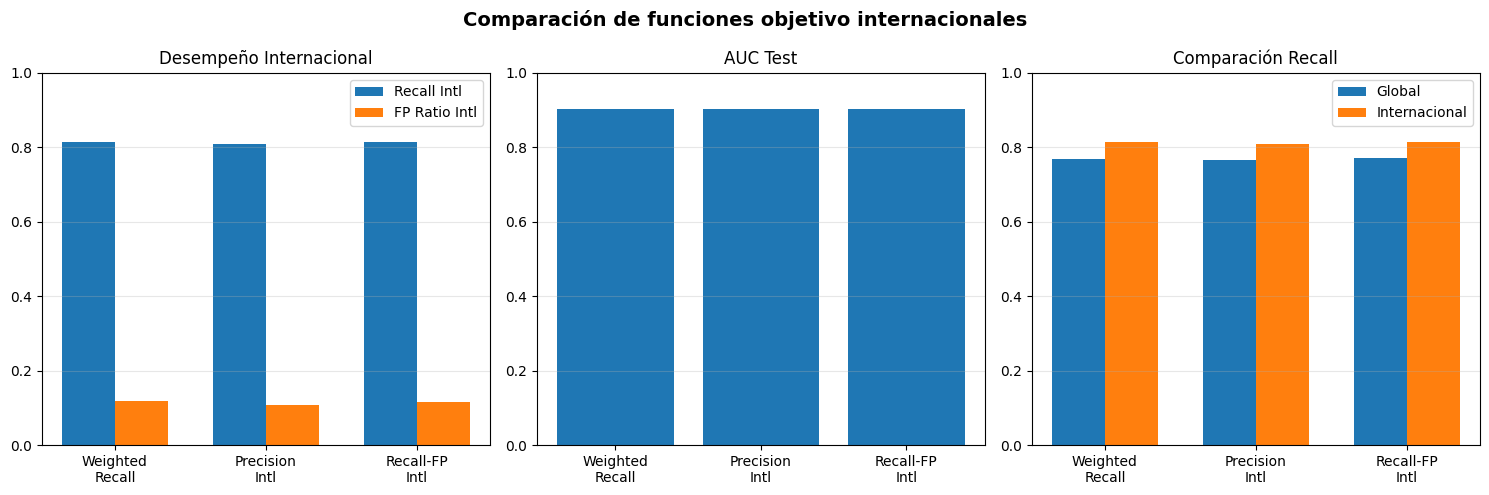

In [40]:
plot_intl_comparison(results_p6)

## Conclusión Paso 6: Optimización para Fraudes Internacionales

El objetivo asignado al grupo fue optimizar la detección de fraudes en transacciones
realizadas fuera del país o en moneda extranjera, identificadas mediante las variables
`is_international` e `is_foreign_currency`.

Para esto se diseñaron dos funciones feval que evalúan el modelo específicamente sobre
este subconjunto de transacciones, en lugar de optimizar de forma global.

La función `feval_intl_precision` priorizó reducir las falsas alarmas dentro del
subconjunto internacional, logrando un FP_ratio internacional de 10.8% y detectando
249 fraudes internacionales. Si bien tiene menos falsos positivos, deja sin detectar
2 fraudes adicionales respecto al otro modelo.

La función `feval_intl_weighted_recall` ponderó el recall dando mayor importancia a
las transacciones internacionales (70%) respecto a las locales (30%), logrando detectar
251 fraudes internacionales con un recall internacional de 81.5% y un FP_ratio de 11.9%.

### Modelo Seleccionado: feval_intl_weighted_recall

Se seleccionó esta función porque detecta más fraudes internacionales y tiene el recall
internacional más alto, alineado directamente con el objetivo del grupo. En el contexto
de clientes VIP, cada fraude internacional no detectado representa un riesgo mayor dado
que estos montos son más altos y más difíciles de revertir. La diferencia de FP_ratio
entre ambas funciones (11.9% vs 10.8%) es marginal y no justifica sacrificar la
detección de fraudes reales. Adicionalmente, el FP_ratio internacional obtenido es
significativamente menor al obtenido en el paso 5 a nivel global (91.1%), lo que
demuestra que focalizar la optimización en el segmento internacional mejora
considerablemente la precisión dentro de ese subconjunto.